In [1]:
# -------------------------
# 1. PILIH VARIABEL NUMERIK
# -------------------------

fitur = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_bidan',
    'jumlah_dokter',
    'jumlah_perawat',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penyakit_menular',
    'jumlah_penduduk'
]

# -------------------------
# 2. STANDARISASI Z-SCORE
# -------------------------

from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[fitur]),
    columns=fitur
)

# -------------------------
# 3. GABUNGKAN DENGAN KOLOM IDENTITAS
# -------------------------

df_zscore = pd.concat(
    [
        df[
            [
                'kode_provinsi',
                'nama_provinsi',
                'kode_kabupaten_kota',
                'nama_kabupaten_kota',
                'tahun'
            ]
        ].reset_index(drop=True),

        df_scaled.reset_index(drop=True)
    ],
    axis=1
)

# -------------------------
# 4. CEK HASIL
# -------------------------

print("Rata-rata setelah standarisasi:")
print(df_scaled.mean())

print("\nStandar deviasi setelah standarisasi:")
print(df_scaled.std())

display(df_zscore.head())

Rata-rata setelah standarisasi:
pelayanan_non_rawat_inap         0.000000e+00
pelayanan_rawat_inap            -8.180591e-17
jumlah_bidan                     9.349247e-17
jumlah_dokter                   -3.339017e-18
jumlah_perawat                  -2.671213e-17
jumlah_penyakit_tidak_menular   -8.013640e-17
jumlah_penyakit_menular          1.335607e-17
jumlah_penduduk                  8.347542e-17
dtype: float64

Standar deviasi setelah standarisasi:
pelayanan_non_rawat_inap         1.001885
pelayanan_rawat_inap             1.001885
jumlah_bidan                     1.001885
jumlah_dokter                    1.001885
jumlah_perawat                   1.001885
jumlah_penyakit_tidak_menular    1.001885
jumlah_penyakit_menular          1.001885
jumlah_penduduk                  1.001885
dtype: float64


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423485,-0.737864
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394990,-0.182574
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424552,-0.503987
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390723,0.039162
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408247,0.220573


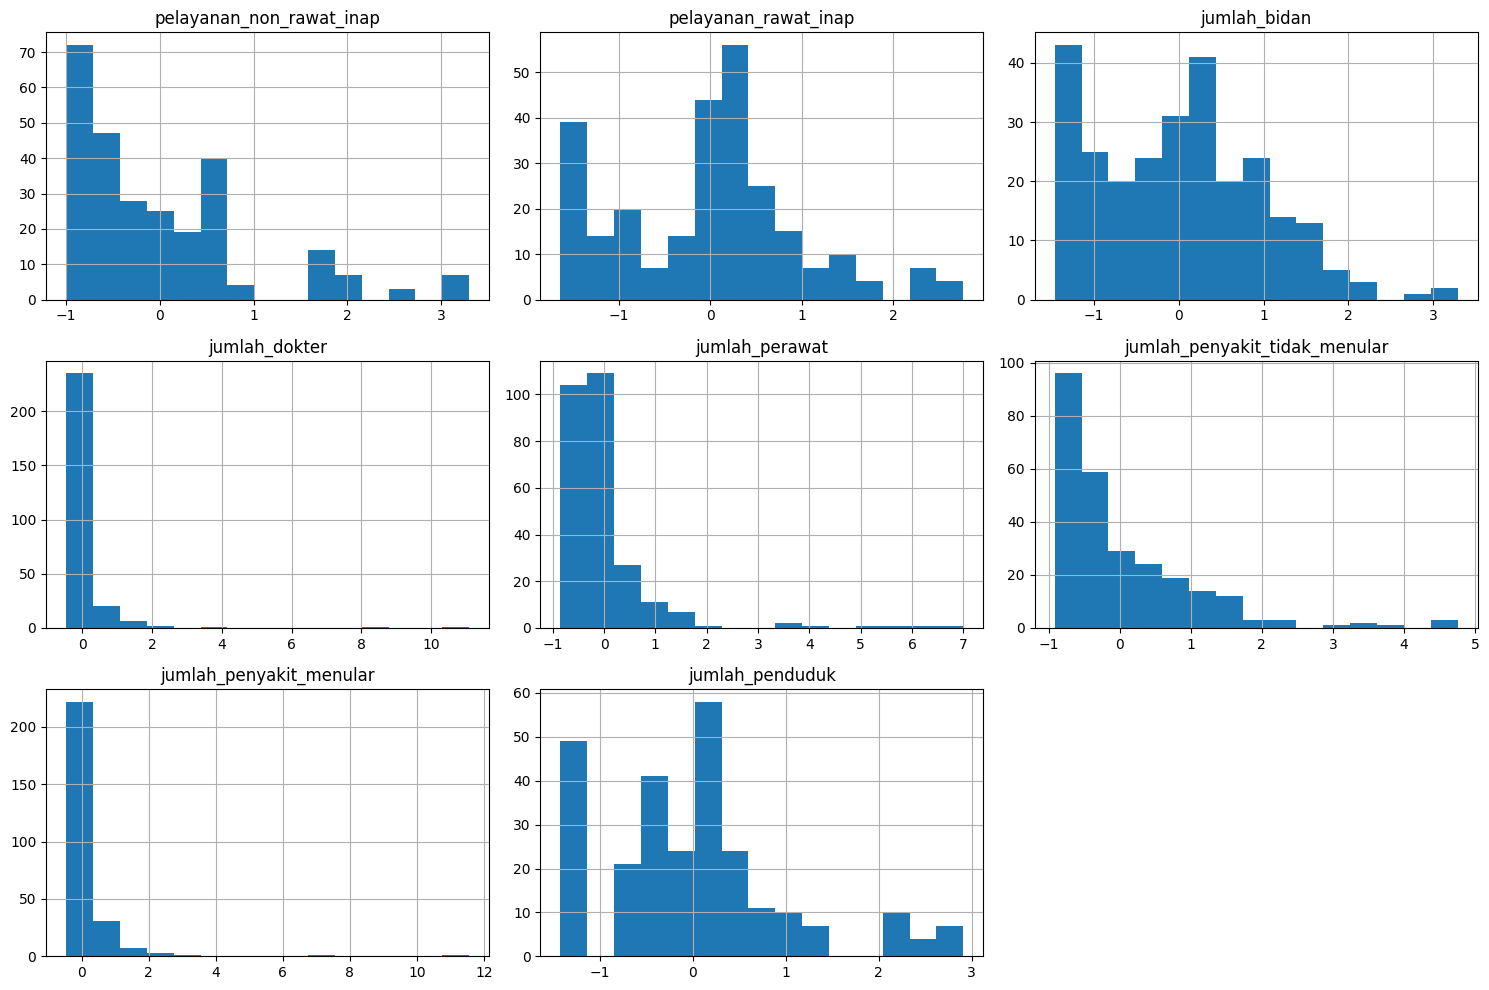

In [2]:
import matplotlib.pyplot as plt

df_scaled.hist(
    figsize=(15,10),
    bins=15
)

plt.tight_layout()
plt.show()

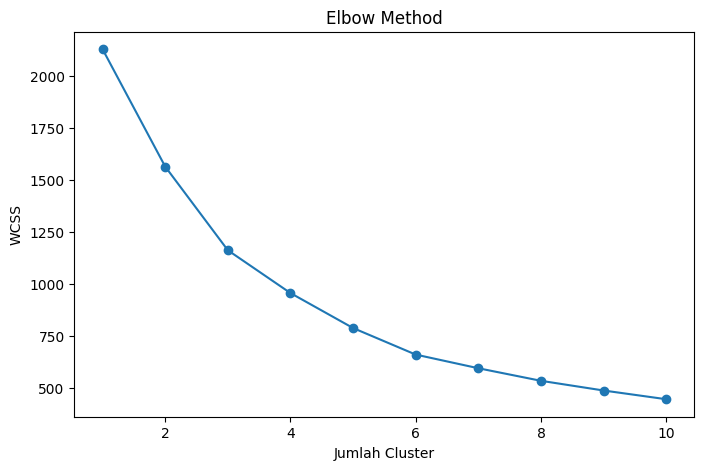

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [4]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

hasil = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)

    hasil.append([k, score])

hasil = pd.DataFrame(
    hasil,
    columns=['Jumlah Cluster', 'Silhouette Score']
)

display(hasil)

,Jumlah Cluster,Silhouette Score
0,2,0.696053
1,3,0.329686
2,4,0.277663
3,5,0.276202
4,6,0.311897
5,7,0.319829
6,8,0.310097
7,9,0.296958
8,10,0.307606


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_hasil = df_scaled.copy()
df_hasil['cluster'] = kmeans.fit_predict(df_scaled)

In [6]:
df_hasil['cluster'].value_counts().sort_index()

cluster
0    185
1     79
2      2
Name: count, dtype: int64

In [7]:
profil_cluster = (
    df_hasil
    .groupby('cluster')
    [
        [
            'pelayanan_non_rawat_inap',
            'pelayanan_rawat_inap',
            'jumlah_bidan',
            'jumlah_dokter',
            'jumlah_perawat',
            'jumlah_penyakit_tidak_menular',
            'jumlah_penyakit_menular',
            'jumlah_penduduk'
        ]
    ]
    .mean()
    .round(2)
)

display(profil_cluster)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,
0,-0.30,-0.25,-0.44,-0.21,-0.34,-0.34,-0.20,-0.46
1,0.61,0.56,0.96,0.24,0.64,0.77,0.23,1.01
2,3.30,0.62,3.15,9.87,6.24,1.31,9.34,2.85


In [8]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(
    df_scaled,
    df_hasil['cluster']
)

dbi = davies_bouldin_score(
    df_scaled,
    df_hasil['cluster']
)

chi = calinski_harabasz_score(
    df_scaled,
    df_hasil['cluster']
)

print("=== Evaluasi K-Means ===")
print(f"Silhouette Score      : {silhouette:.4f}")
print(f"Davies-Bouldin Index  : {dbi:.4f}")
print(f"Calinski-Harabasz     : {chi:.4f}")

=== Evaluasi K-Means ===
Silhouette Score      : 0.3297
Davies-Bouldin Index  : 1.0839
Calinski-Harabasz     : 109.2185


In [9]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

cluster_agglo = agglo.fit_predict(df_scaled)

df_agglo = df_scaled.copy()
df_agglo['cluster'] = cluster_agglo

df_agglo.head()

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster
0,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423485,-0.737864,2
1,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394990,-0.182574,2
2,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424552,-0.503987,2
3,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390723,0.039162,2
4,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408247,0.220573,2


In [10]:
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

# Evaluasi
silhouette = silhouette_score(df_scaled, cluster_agglo)
dbi = davies_bouldin_score(df_scaled, cluster_agglo)
chi = calinski_harabasz_score(df_scaled, cluster_agglo)

# Tabel hasil evaluasi
hasil_evaluasi = pd.DataFrame({
    'Metode': ['Agglomerative Hierarchical Clustering'],
    'Silhouette Coefficient': [round(silhouette, 4)],
    'Davies-Bouldin Index': [round(dbi, 4)],
    'Calinski-Harabasz Index': [round(chi, 4)]
})

display(hasil_evaluasi)

,Metode,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index
0,Agglomerative Hierarchical Clustering,0.2572,1.0976,100.1429


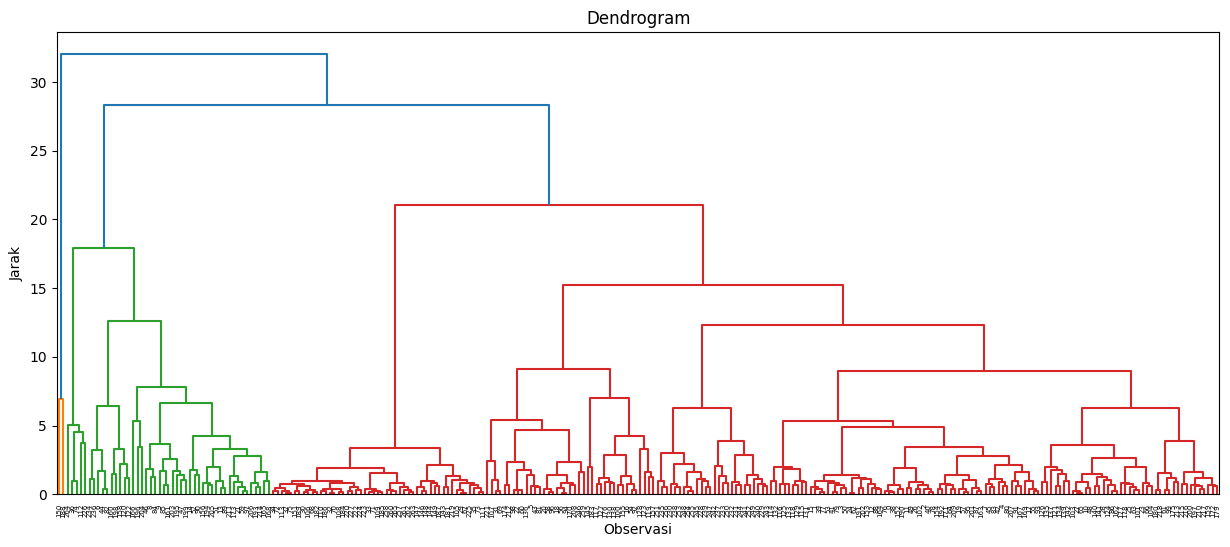

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(
    df_scaled,
    method='ward'
)

plt.figure(figsize=(15,6))

dendrogram(Z)

plt.title('Dendrogram')
plt.xlabel('Observasi')
plt.ylabel('Jarak')
plt.show()

In [12]:
profil_agglo = (
    df_agglo
    .groupby('cluster')
    [
        [
            'pelayanan_non_rawat_inap',
            'pelayanan_rawat_inap',
            'jumlah_bidan',
            'jumlah_dokter',
            'jumlah_perawat',
            'jumlah_penyakit_tidak_menular',
            'jumlah_penyakit_menular',
            'jumlah_penduduk'
        ]
    ]
    .mean()
    .round(2)
)

display(profil_agglo)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,
0,0.71,0.80,0.95,0.12,0.89,1.35,0.14,1.41
1,3.30,0.62,3.15,9.87,6.24,1.31,9.34,2.85
2,-0.08,0.19,-0.02,-0.08,-0.18,-0.18,-0.07,-0.05
3,-0.56,-1.44,-0.98,-0.23,-0.48,-0.72,-0.28,-1.31


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

hasil_evaluasi = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    silhouette = silhouette_score(df_scaled, labels)
    dbi = davies_bouldin_score(df_scaled, labels)
    chi = calinski_harabasz_score(df_scaled, labels)

    hasil_evaluasi.append([
        k,
        round(silhouette, 4),
        round(dbi, 4),
        round(chi, 4)
    ])

hasil_evaluasi = pd.DataFrame(
    hasil_evaluasi,
    columns=[
        'Jumlah Cluster',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index'
    ]
)

display(hasil_evaluasi)

,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.6961,0.9043,95.1562
1,3,0.3297,1.0839,109.2185
2,4,0.2777,1.0532,106.8931
3,5,0.2762,1.1339,110.7681
4,6,0.3119,1.0225,115.3148
5,7,0.3198,1.0382,111.0183
6,8,0.3101,1.1456,109.6326
7,9,0.2970,1.0945,107.7188
8,10,0.3076,1.0879,106.9730


In [14]:
print("Cluster terbaik berdasarkan Silhouette:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Silhouette Score'].idxmax()
    ]
)

print("\nCluster terbaik berdasarkan DBI:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Davies-Bouldin Index'].idxmin()
    ]
)

print("\nCluster terbaik berdasarkan CHI:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Calinski-Harabasz Index'].idxmax()
    ]
)

Cluster terbaik berdasarkan Silhouette:


Jumlah Cluster              2.0000
Silhouette Score            0.6961
Davies-Bouldin Index        0.9043
Calinski-Harabasz Index    95.1562
Name: 0, dtype: float64


Cluster terbaik berdasarkan DBI:


Jumlah Cluster              2.0000
Silhouette Score            0.6961
Davies-Bouldin Index        0.9043
Calinski-Harabasz Index    95.1562
Name: 0, dtype: float64


Cluster terbaik berdasarkan CHI:


Jumlah Cluster               6.0000
Silhouette Score             0.3119
Davies-Bouldin Index         1.0225
Calinski-Harabasz Index    115.3148
Name: 4, dtype: float64